In [1]:
import uproot
import awkward as ak

In [2]:
file_name = "test_jetTuple_extended_5.root"

In [3]:
infile = uproot.open(file_name)

In [4]:
keys = infile.keys()
print(keys)

['outnano;1', 'outnano/h_genPtRes;1', 'outnano/h_jet_genmatchLLPdaughter_n;1', 'outnano/h_genLLP_daughter_eta;1', 'outnano/h_genLLP_daughter_phi;1', 'outnano/h_genLLP_daughter_pt;1', 'outnano/h_genLLP_eta;1', 'outnano/h_genLLP_phi;1', 'outnano/h_genLLP_pt;1', 'outnano/h_nGenLLP;1', 'outnano/h_nGenLLPDaughter;1', 'outnano/h_GenJet_eta;1', 'outnano/h_GenJet_eta_matched;1', 'outnano/Jets;1']


In [10]:
h = infile["outnano/h_jet_genmatchLLPdaughter_n"]

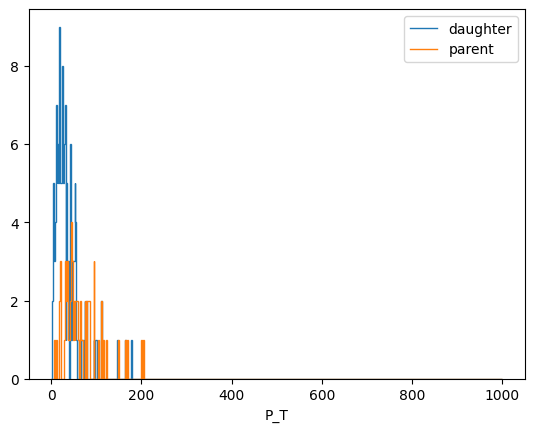

In [18]:
import uproot
import matplotlib.pyplot as plt

f = uproot.open("test_jetTuple_extended_5.root")
h = f["outnano/h_genLLP_daughter_pt"]

counts, edges = h.to_numpy()
plt.stairs(counts, edges, label="daughter")
plt.xlabel(r"P_T")



h2 = f["outnano/h_genLLP_pt"]
counts, edges = h2.to_numpy()
plt.stairs(counts, edges, label="parent")
plt.xlabel(r"P_T")

plt.legend()
plt.show()



In [20]:
events = infile['outnano/Jets']

In [21]:
print(type(events))

<class 'uproot.models.TTree.Model_TTree_v20'>


In [22]:
branches = events.keys()

In [23]:
for branch in branches:
    print(f"{branch:20s} {events[branch]}")

event                <TBranch 'event' at 0x7ff7658c5330>
ngenH                <TBranch 'ngenH' at 0x7ff7658c5b70>
genH_pt              <TBranchElement 'genH_pt' at 0x7ff7658c6320>
genH_mass            <TBranchElement 'genH_mass' at 0x7ff7658c6c20>
genHH_pt             <TBranch 'genHH_pt' at 0x7ff7658c7580>
genHH_mass           <TBranch 'genHH_mass' at 0x7ff7658c7d90>
jet_eta              <TBranch 'jet_eta' at 0x7ff7658ec580>
jet_eta_phys         <TBranch 'jet_eta_phys' at 0x7ff7658ecd30>
jet_phi              <TBranch 'jet_phi' at 0x7ff7658ed4e0>
jet_phi_phys         <TBranch 'jet_phi_phys' at 0x7ff7658edc90>
jet_pt               <TBranch 'jet_pt' at 0x7ff7658ee440>
jet_pt_phys          <TBranch 'jet_pt_phys' at 0x7ff7658eebf0>
jet_pt_raw           <TBranch 'jet_pt_raw' at 0x7ff7658ef3a0>
jet_mass             <TBranch 'jet_mass' at 0x7ff7658efb50>
jet_energy           <TBranch 'jet_energy' at 0x7ff765908340>
jet_SC4NGJet_score_b <TBranch 'jet_SC4NGJet_score_b' at 0x7ff765908af0>
jet_SC4

In [24]:
import matplotlib.pyplot as plt

In [25]:
import mplhep as hep
plt.style.use(hep.style.ROOT)

import matplotlib.pylab as pylab
params = {'legend.fontsize': 'medium',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'medium',
         'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

#line thickness
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2

In [26]:
llpjet_match_mask = events["jet_doesmatch_genLLPDecay"].array() #per jet flag

In [27]:
track_vx = events['jet_pfcand_track_vx'].array()

In [28]:
track_vx[0]

<Array [0.000514, -0.000531, 0.00764, 0.014, -0.013, 0] type='6 * float32'>

Text(0, 1, 'Number of Constituents')

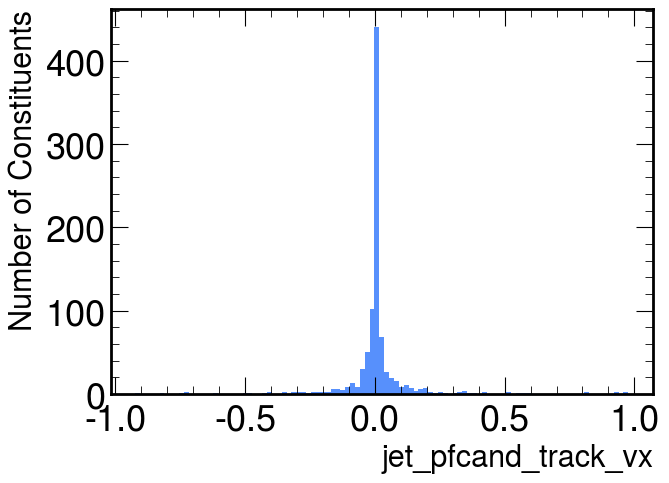

In [29]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(ak.flatten(track_vx), bins=101, );
ax.set_xlabel("jet_pfcand_track_vx", fontsize=22)
ax.set_ylabel("Number of Constituents", fontsize=22)


In [30]:
track_vz = events['jet_pfcand_track_vz'].array()

Text(0, 1, 'Number of Constituents')

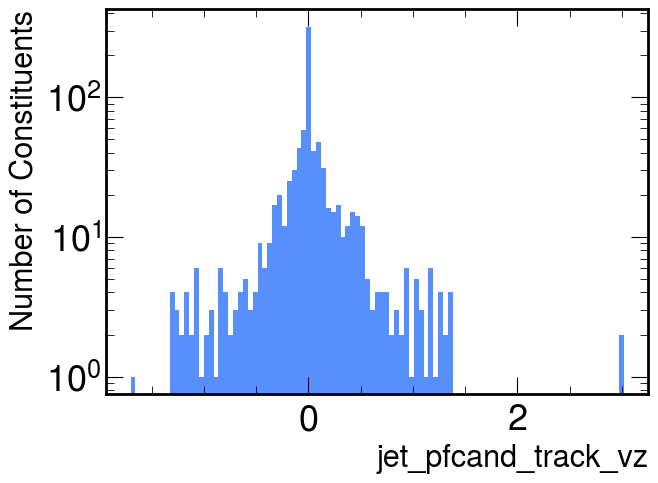

In [31]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(ak.flatten(track_vz), bins=101, );
ax.set_yscale("log")
ax.set_xlabel("jet_pfcand_track_vz", fontsize=22)
ax.set_ylabel("Number of Constituents", fontsize=22)

In [32]:
max(ak.flatten(track_vz))

3.0175781

matching flag at pf candidate level: 1 for particles matched to and llp. Also, removed jets with no matching pf candidates.

In [48]:
maybe_signal_jet_pfcand_vx = events['jet_pfcand_track_vx'].array()[events["jet_doesmatch_genLLPDecay"].array()]

Text(0, 1, 'Number of Constituents')

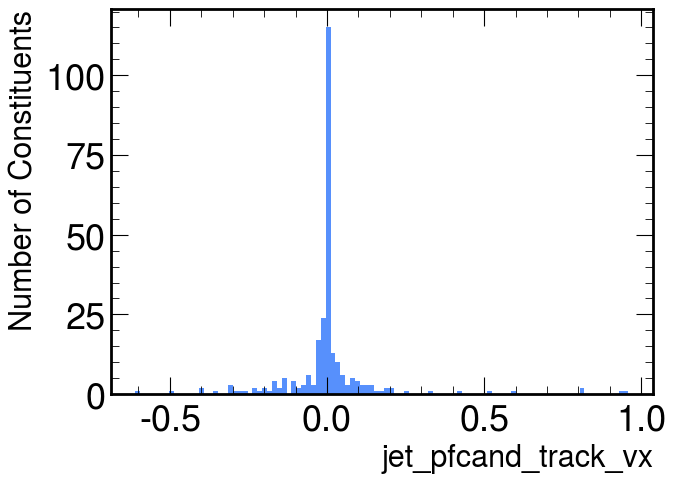

In [49]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(ak.flatten(maybe_signal_jet_pfcand_vx), bins=101, );
ax.set_xlabel("jet_pfcand_track_vx", fontsize=22)
ax.set_ylabel("Number of Constituents", fontsize=22)

In [44]:
maybe_signal_jet_pfcand_vz = events['jet_pfcand_track_vz'].array()[events["jet_doesmatch_genLLPDecay"].array()]

Text(0, 1, 'Number of Constituents')

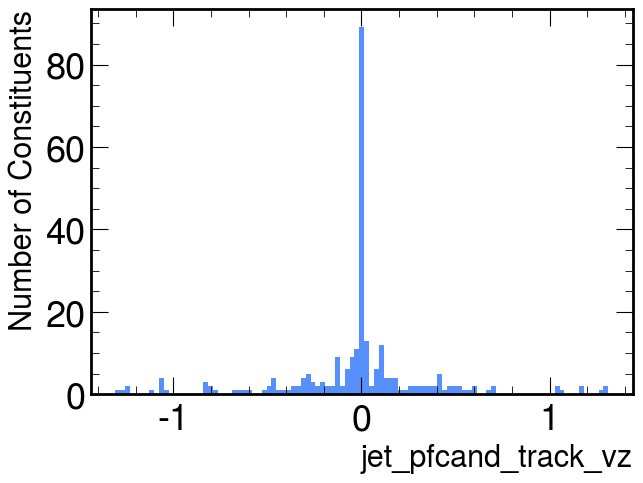

In [45]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(ak.flatten(maybe_signal_jet_pfcand_vz), bins=101, );
ax.set_xlabel("jet_pfcand_track_vz", fontsize=22)
ax.set_ylabel("Number of Constituents", fontsize=22)

matching flag at jet level: Distribution includes pf cands that did and did NOT come from an LLP, but are inside the jet

In [46]:
matched_track_vx = ak.flatten(events['jet_pfcand_track_vx'].array()[events["jet_doesmatch_genLLPDecay"].array()])

Text(0, 1, 'Number of Constituents')

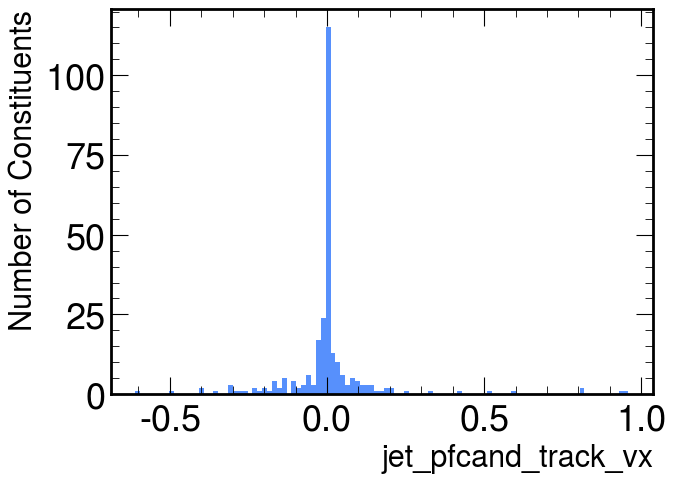

In [47]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(matched_track_vx, bins=101, );
ax.set_xlabel("jet_pfcand_track_vx", fontsize=22)
ax.set_ylabel("Number of Constituents", fontsize=22)


**The rows correspond to a jet, not an event**. I select npcand's that have a pf candidate matched to the LLP.

In [50]:
npfcand = events['jet_npfcand'].array()[events["jet_doesmatch_genLLPDecay"].array()]

In [51]:
npfcand #seems more like jets per event and not particles per jet, but it seems to be # jet constituents (no event info)

<Array [5, 3, 3, 3, 3, 3, 7, 6, ..., 7, 4, 5, 5, 6, 2, 3, 6] type='57 * uint32'>

Text(0, 1, 'Number of Jets')

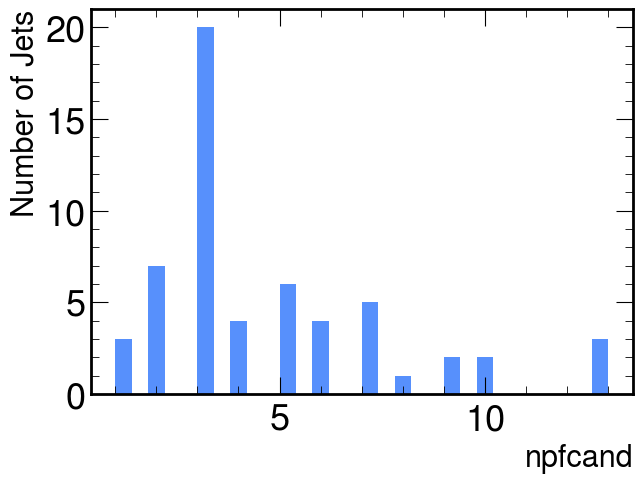

In [52]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(npfcand, bins=30, );
ax.set_xlabel("npfcand", fontsize=22)
ax.set_ylabel("Number of Jets", fontsize=22)